In [2]:
# =========================================================
# 🧹 MarketSense | Phase 1 — Environment Setup (Stable)
# =========================================================
!pip install -q torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0
!pip install -q transformers==4.44.0 feedparser==6.0.11 yfinance==0.2.50 pandas==2.2.2 scipy==1.12.0 matplotlib==3.9.2
!pip install -q tqdm==4.66.5
!pip install -q seaborn==0.13.2
!pip install -q datasets==3.0.1
print("✅ All core packages installed successfully — restart runtime now (Runtime → Restart runtime) before continuing.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 72.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confli

In [1]:
import torch, transformers, pandas as pd, feedparser, yfinance, matplotlib, scipy
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("✅ Environment looks good — ready for Phase 2.")


Torch: 2.8.0+cu126
Transformers: 4.44.0
Pandas: 2.2.2
SciPy: 1.12.0
✅ Environment looks good — ready for Phase 2.


In [2]:
# =========================================================
# MarketSense — Phase 2.1: Config
# =========================================================
from datetime import datetime, timezone
import os, random
import numpy as np

# ---- Project settings
TICKERS = ["AAPL","NVDA","MSFT","AMZN","TSLA","JPM","GS","MS","WMT"]

# Choose a fixed, reproducible window (adjust anytime)
SINCE = datetime(2025, 4, 1, tzinfo=timezone.utc)
UNTIL = datetime(2025, 10, 20, tzinfo=timezone.utc)

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Output files
RAW_HEADLINES_CSV = "headlines.csv"
SCORED_HEADLINES_CSV = "headlines_scored.csv"

def log(msg): print(f"[INFO] {msg}")


In [3]:
# =========================================================
# MarketSense — Phase 2.2: Fetch Headlines (RSS)
# =========================================================
import feedparser, time
from urllib.parse import quote
import pandas as pd

def normalize_headline(s: str) -> str:
    return " ".join(str(s).replace("\n"," ").split())

def fetch_rss_headlines_for_ticker(ticker, since_dt, until_dt, max_items=250):
    """
    Query pattern: "{TICKER} stock" from Google News RSS.
    Filter strictly inside [since_dt, until_dt] (UTC).
    """
    q = quote(f"{ticker} stock")
    url = f"https://news.google.com/rss/search?q={q}&hl=en-US&gl=US&ceid=US:en"
    d = feedparser.parse(url)

    rows = []
    for entry in d.entries[:max_items]:
        title = (entry.get("title") or "").strip()
        if not title:
            continue
        published_parsed = entry.get("published_parsed")
        if not published_parsed:
            continue
        pub_dt = datetime(*published_parsed[:6], tzinfo=timezone.utc)
        if not (since_dt <= pub_dt <= until_dt):
            continue
        rows.append({
            "ticker": ticker,
            "published_utc": pub_dt.isoformat(),
            "headline": normalize_headline(title),
            "source_url": entry.get("link",""),
            "source": entry.get("source",{}).get("title","") if isinstance(entry.get("source"), dict) else "",
        })
    return rows

log(f"Collecting headlines from {SINCE.date()} to {UNTIL.date()}")
all_rows = []
for t in TICKERS:
    try:
        r = fetch_rss_headlines_for_ticker(t, SINCE, UNTIL)
        all_rows.extend(r)
        time.sleep(0.8)  # polite pause
    except Exception as e:
        log(f"[WARN] {t}: {e}")

# Build frame, de-dupe by ticker+headline (conservative)
headlines_df = pd.DataFrame(all_rows)
if len(headlines_df):
    headlines_df = headlines_df.drop_duplicates(subset=["ticker","headline"]).copy()
    headlines_df["date"] = pd.to_datetime(headlines_df["published_utc"]).dt.date.astype(str)
    headlines_df = headlines_df[["date","ticker","headline","source","source_url","published_utc"]].sort_values(["date","ticker"])
else:
    headlines_df = pd.DataFrame(columns=["date","ticker","headline","source","source_url","published_utc"])

print("Rows:", len(headlines_df))
print("Date range:", headlines_df["date"].min(), "→", headlines_df["date"].max() if len(headlines_df) else None)
print("\nPer-ticker counts:\n", headlines_df.groupby("ticker")["headline"].count() if len(headlines_df) else "—")

# Save raw headlines for reproducibility
headlines_df.to_csv(RAW_HEADLINES_CSV, index=False)
headlines_df.head(10)


[INFO] Collecting headlines from 2025-04-01 to 2025-10-20
Rows: 287
Date range: 2025-06-25 → 2025-10-19

Per-ticker counts:
 ticker
AMZN    40
GS      59
JPM     42
MS      33
MSFT    23
NVDA    14
TSLA    40
WMT     36
Name: headline, dtype: int64


,date,ticker,headline,source,source_url,published_utc
245,2025-06-25,MS,Morgan Stanley (MS) Stock Moves 1.34%: What Yo...,Yahoo Finance,https://news.google.com/rss/articles/CBMigAFBV...,2025-06-25T07:00:00+00:00
148,2025-07-01,JPM,JPMorganChase Plans Dividend Increase and Has ...,JPMorganChase,https://news.google.com/rss/articles/CBMihwFBV...,2025-07-01T07:00:00+00:00
162,2025-07-07,JPM,How Will JPMorgan Chase Stock React To Its Upc...,Trefis,https://news.google.com/rss/articles/CBMivAFBV...,2025-07-07T07:00:00+00:00
144,2025-07-08,JPM,Why JPMorgan Chase (JPM) Stock Is Falling Toda...,Yahoo Finance,https://news.google.com/rss/articles/CBMif0FVX...,2025-07-08T07:00:00+00:00
217,2025-07-16,GS,"Goldman Sachs Delivers Q2 Powerhouse, Stock Se...",Yahoo Finance,https://news.google.com/rss/articles/CBMiigFBV...,2025-07-16T07:00:00+00:00
220,2025-07-24,GS,Can the US Stock Rally Persist as the Dollar D...,Goldman Sachs,https://news.google.com/rss/articles/CBMilwFBV...,2025-07-24T07:00:00+00:00
77,2025-07-27,AMZN,Amazon (AMZN) Stock Target Raised to $265 as A...,Yahoo Finance,https://news.google.com/rss/articles/CBMigwFBV...,2025-07-27T07:00:00+00:00
71,2025-07-28,AMZN,Amazon (AMZN) Stock Climb on Massive Price Tar...,Yahoo Finance,https://news.google.com/rss/articles/CBMigwFBV...,2025-07-28T07:00:00+00:00
275,2025-07-31,WMT,WMT Stock: A Strong Buy for Investors Seeking ...,Yahoo Finance,https://news.google.com/rss/articles/CBMiggFBV...,2025-07-31T07:00:00+00:00
75,2025-08-04,AMZN,Amazon (AMZN) Stock Dips Despite Q2 2025 Beat:...,CarbonCredits.com,https://news.google.com/rss/articles/CBMisAFBV...,2025-08-04T07:00:00+00:00


In [4]:
# =========================================================
# MarketSense — Phase 2.3: Sentiment Scoring (FinBERT + DistilBERT)
# =========================================================
import pandas as pd
from transformers import pipeline
import torch
from tqdm import tqdm

if not len(headlines_df):
    raise SystemExit("No headlines found. Re-run Cell 2.2 with a wider date window or different tickers.")

device = 0 if torch.cuda.is_available() else -1
print("Using device:", "GPU" if device==0 else "CPU")

# Pipelines (domain vs general)
finbert = pipeline("text-classification", model="ProsusAI/finbert", return_all_scores=True, device=device)
distil  = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english", return_all_scores=True, device=device)

def scores_to_sentiment(scores, labels_order):
    """
    Convert label probabilities to a single signed sentiment in [-1, 1].
    For FinBERT: labels ['positive','negative','neutral'].
    For DistilBERT SST-2: labels ['NEGATIVE','POSITIVE'].
    """
    d = {s["label"].lower(): float(s["score"]) for s in scores}
    # handle missing labels safely
    for lab in labels_order:
        d.setdefault(lab.lower(), 0.0)

    if set(map(str.lower, labels_order)) == {"positive","negative","neutral"}:
        pos, neg, neu = d["positive"], d["negative"], d["neutral"]
        # map to [-1,1], treat neutral as 0, and renormalize lightly
        return (pos - neg)
    else:
        # SST-2 style: POSITIVE/NEGATIVE only
        pos = d.get("positive", d.get("positive".upper(), 0.0))
        neg = d.get("negative", d.get("negative".upper(), 0.0))
        return (pos - neg)

finbert_labels = ["positive","negative","neutral"]
distil_labels  = ["NEGATIVE","POSITIVE"]

texts = headlines_df["headline"].tolist()
finbert_sent = []
distil_sent  = []

# Batch for speed
B = 32
for i in tqdm(range(0, len(texts), B), desc="Scoring"):
    batch = texts[i:i+B]
    f_out = finbert(batch)
    d_out = distil(batch)

    # f_out/d_out are lists of list-of-dicts
    for f_scores, d_scores in zip(f_out, d_out):
        finbert_sent.append(scores_to_sentiment(f_scores, finbert_labels))
        distil_sent.append(scores_to_sentiment(d_scores, distil_labels))

scored = headlines_df.copy()
scored["finbert_sent"] = finbert_sent
scored["distil_sent"]  = distil_sent

print("Scored rows:", len(scored))
scored.to_csv(SCORED_HEADLINES_CSV, index=False)
scored.head(10)


Using device: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Scoring: 100%|██████████| 9/9 [00:05<00:00,  1.70it/s]

Scored rows: 287


,date,ticker,headline,source,source_url,published_utc,finbert_sent,distil_sent
245,2025-06-25,MS,Morgan Stanley (MS) Stock Moves 1.34%: What Yo...,Yahoo Finance,https://news.google.com/rss/articles/CBMigAFBV...,2025-06-25T07:00:00+00:00,-0.043588,-0.964482
148,2025-07-01,JPM,JPMorganChase Plans Dividend Increase and Has ...,JPMorganChase,https://news.google.com/rss/articles/CBMihwFBV...,2025-07-01T07:00:00+00:00,0.760526,0.681196
162,2025-07-07,JPM,How Will JPMorgan Chase Stock React To Its Upc...,Trefis,https://news.google.com/rss/articles/CBMivAFBV...,2025-07-07T07:00:00+00:00,0.019185,-0.993380
144,2025-07-08,JPM,Why JPMorgan Chase (JPM) Stock Is Falling Toda...,Yahoo Finance,https://news.google.com/rss/articles/CBMif0FVX...,2025-07-08T07:00:00+00:00,-0.907558,-0.999395
217,2025-07-16,GS,"Goldman Sachs Delivers Q2 Powerhouse, Stock Se...",Yahoo Finance,https://news.google.com/rss/articles/CBMiigFBV...,2025-07-16T07:00:00+00:00,0.602352,0.997926
220,2025-07-24,GS,Can the US Stock Rally Persist as the Dollar D...,Goldman Sachs,https://news.google.com/rss/articles/CBMilwFBV...,2025-07-24T07:00:00+00:00,-0.750343,-0.998245
77,2025-07-27,AMZN,Amazon (AMZN) Stock Target Raised to $265 as A...,Yahoo Finance,https://news.google.com/rss/articles/CBMigwFBV...,2025-07-27T07:00:00+00:00,0.918673,-0.992473
71,2025-07-28,AMZN,Amazon (AMZN) Stock Climb on Massive Price Tar...,Yahoo Finance,https://news.google.com/rss/articles/CBMigwFBV...,2025-07-28T07:00:00+00:00,0.667472,-0.984893
275,2025-07-31,WMT,WMT Stock: A Strong Buy for Investors Seeking ...,Yahoo Finance,https://news.google.com/rss/articles/CBMiggFBV...,2025-07-31T07:00:00+00:00,0.839363,0.997333
75,2025-08-04,AMZN,Amazon (AMZN) Stock Dips Despite Q2 2025 Beat:...,CarbonCredits.com,https://news.google.com/rss/articles/CBMisAFBV...,2025-08-04T07:00:00+00:00,-0.851605,-0.999160


In [5]:
# =========================================================
# MarketSense — Phase 2.4: Daily Aggregation (per ticker)
# =========================================================
import pandas as pd

scored = pd.read_csv(SCORED_HEADLINES_CSV, parse_dates=["published_utc"])
scored["date"] = pd.to_datetime(scored["date"]).dt.date.astype(str)

daily_sent = (
    scored.groupby(["date","ticker"], as_index=False)[["finbert_sent","distil_sent"]]
    .mean()
    .sort_values(["date","ticker"])
)

print("Daily sentiment rows:", len(daily_sent))
daily_sent.to_csv("daily_sentiment.csv", index=False)
daily_sent.head(10)


Daily sentiment rows: 162


,date,ticker,finbert_sent,distil_sent
0,2025-06-25,MS,-0.043588,-0.964482
1,2025-07-01,JPM,0.760526,0.681196
2,2025-07-07,JPM,0.019185,-0.993380
3,2025-07-08,JPM,-0.907558,-0.999395
4,2025-07-16,GS,0.602352,0.997926
5,2025-07-24,GS,-0.750343,-0.998245
6,2025-07-27,AMZN,0.918673,-0.992473
7,2025-07-28,AMZN,0.667472,-0.984893
8,2025-07-31,WMT,0.839363,0.997333
9,2025-08-04,AMZN,-0.851605,-0.999160


In [6]:
daily_sent.to_csv("daily_sentiment.csv", index=False)
print("✅ daily_sentiment.csv saved")


✅ daily_sentiment.csv saved


In [7]:
import pandas as pd

print("Headlines per ticker:")
print(pd.read_csv("headlines.csv").groupby("ticker").size().sort_values(ascending=False))

print("\nDaily sentiment per ticker:")
print(pd.read_csv("daily_sentiment.csv").groupby("ticker").size().sort_values(ascending=False))


Headlines per ticker:
ticker
GS      59
JPM     42
AMZN    40
TSLA    40
WMT     36
MS      33
MSFT    23
NVDA    14
dtype: int64

Daily sentiment per ticker:
ticker
GS      31
AMZN    23
WMT     23
TSLA    22
JPM     20
MS      18
MSFT    15
NVDA    10
dtype: int64


Tickers: ['AAPL', 'WMT', 'JPM', 'MS', 'GS', 'AMZN', 'MSFT', 'TSLA', 'NVDA']
Sentiment date range: 2025-04-03 → 2025-10-19


ERROR:yfinance:Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AAPL']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


[WARN] Yahoo empty for AAPL (try 1/3)


ERROR:yfinance:Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AAPL']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


[WARN] Yahoo empty for AAPL (try 2/3)


...

[WARN] Yahoo empty for NVDA (try 1/3)


ERROR:yfinance:Failed to get ticker 'NVDA' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NVDA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


[WARN] Yahoo empty for NVDA (try 2/3)


ERROR:yfinance:Failed to get ticker 'NVDA' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NVDA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


[WARN] Yahoo empty for NVDA (try 3/3)
[INFO] Falling back to Stooq for NVDA …
[OK] NVDA price rows: 141
Price rows: 1269
Price date range: 2025-04-01 → 2025-10-21
Merged rows: 237
Aligned days: 85
✅ Saved merged_sentiment_prices.csv
finbert_sent: r=0.145
distil_sent: r=0.068


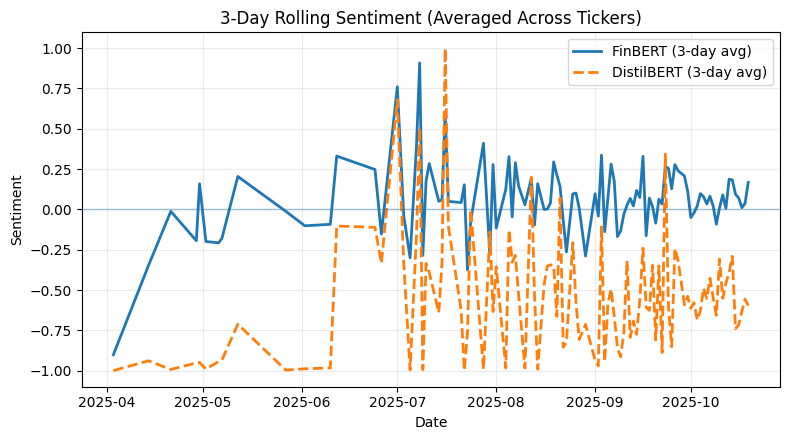

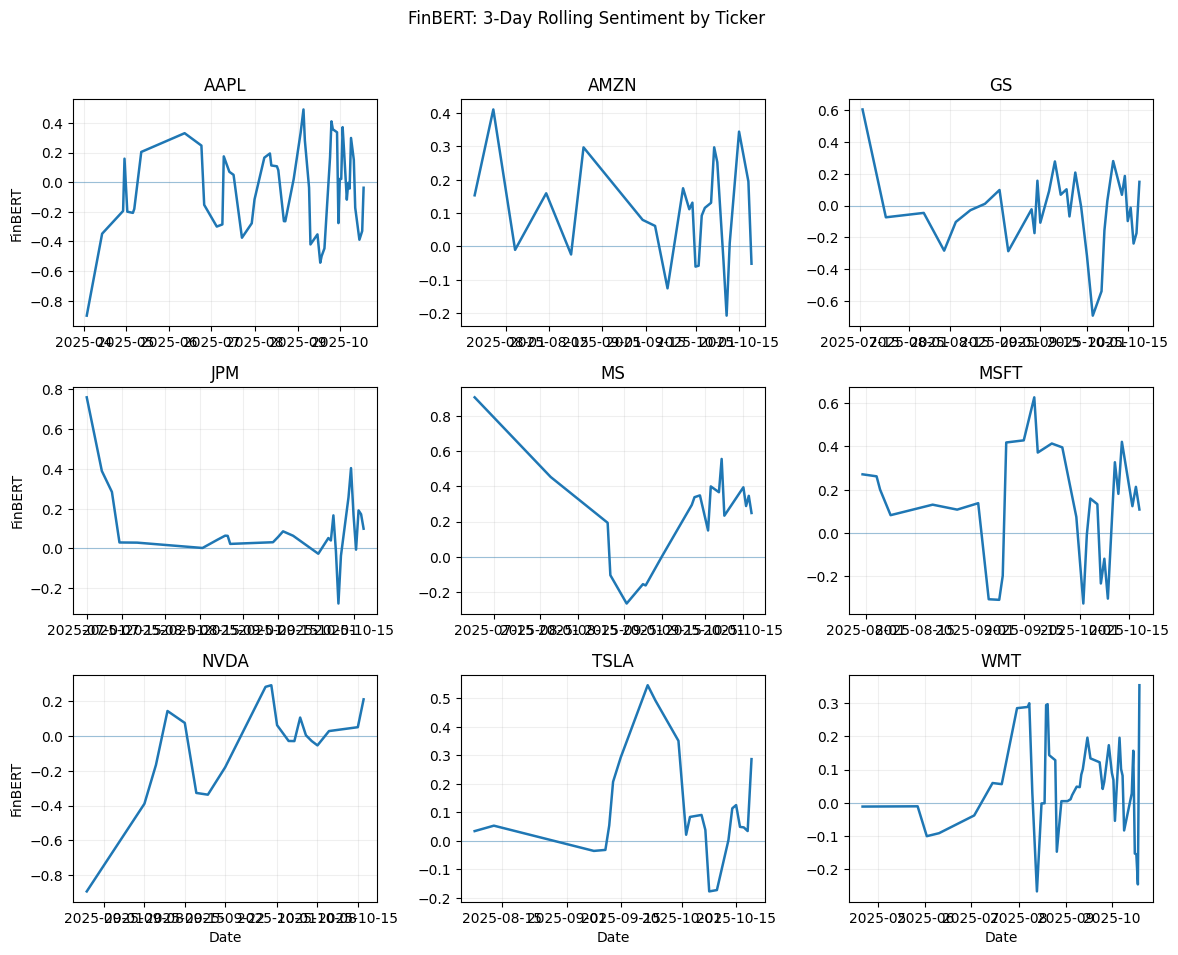

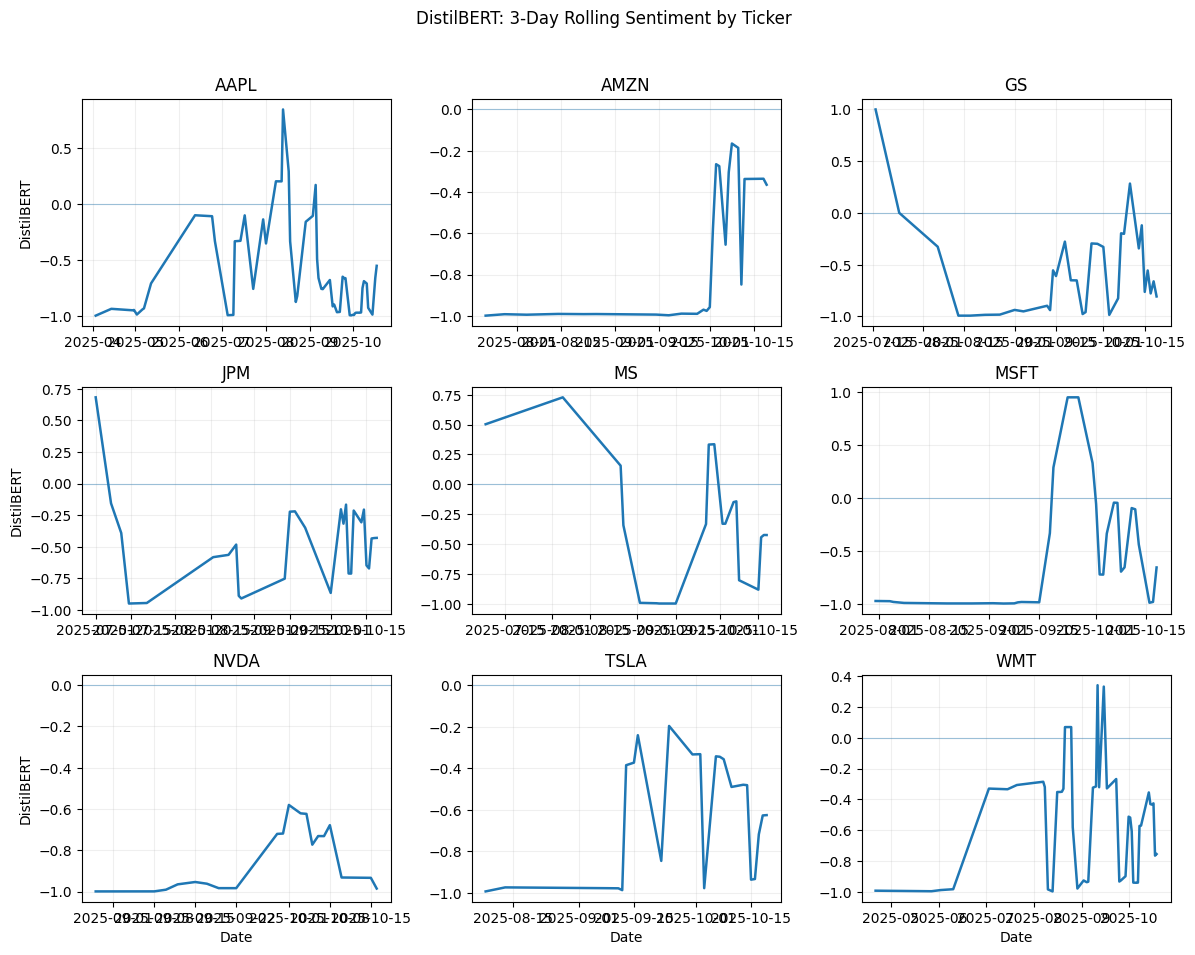

✅ Saved: fig_roll3_overall.png, fig_roll3_finbert_by_ticker.png, fig_roll3_distil_by_ticker.png


In [10]:
# =========================================================
# MarketSense — Phase 3b: Robust Prices (Yahoo + Stooq fallback) + Merge + Figures
# =========================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt, yfinance as yf, time, io, requests
from scipy.stats import pearsonr

# ---------- Load sentiment ----------
daily_sent = pd.read_csv("daily_sentiment.csv")
daily_sent["date"] = pd.to_datetime(daily_sent["date"])
TICKERS = daily_sent["ticker"].unique().tolist()
print("Tickers:", TICKERS)
print("Sentiment date range:", daily_sent["date"].min().date(), "→", daily_sent["date"].max().date())

start_date = daily_sent["date"].min() - pd.Timedelta(days=2)
end_date   = daily_sent["date"].max() + pd.Timedelta(days=2)

# ---------- Helpers ----------
def fetch_yahoo(t, start_date, end_date, retries=3, pause=1.0):
    """Try yfinance with a couple retries; return DataFrame or None."""
    for a in range(retries):
        try:
            df = yf.download(t, start=start_date, end=end_date, progress=False, threads=False)
            if not df.empty:
                out = df.reset_index()[["Date","Open","Close"]].copy()
                out["ticker"] = t
                return out
            else:
                print(f"[WARN] Yahoo empty for {t} (try {a+1}/{retries})")
        except Exception as e:
            print(f"[ERROR] Yahoo {t} (try {a+1}/{retries}): {e}")
        time.sleep(pause)
    return None

def fetch_stooq(t, start_date, end_date):
    """
    Stooq daily CSV. For US stocks use 'symbol.us' lowercased.
    URL pattern: https://stooq.com/q/d/l/?s=aapl.us&i=d
    """
    sym = f"{t.lower()}.us"
    url = f"https://stooq.com/q/d/l/?s={sym}&i=d"
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
        if df.empty or "Date" not in df:
            print(f"[WARN] Stooq empty/invalid for {t}")
            return None
        df["Date"] = pd.to_datetime(df["Date"])
        # Filter to our window
        m = (df["Date"] >= pd.to_datetime(start_date)) & (df["Date"] <= pd.to_datetime(end_date))
        df = df.loc[m, ["Date","Open","Close"]].copy()
        if df.empty:
            print(f"[WARN] Stooq no rows in window for {t}")
            return None
        df["ticker"] = t
        return df
    except Exception as e:
        print(f"[ERROR] Stooq {t}: {e}")
        return None

# ---------- Fetch prices with fallback ----------
price_rows = []
for t in TICKERS:
    got = fetch_yahoo(t, start_date, end_date)
    if got is None:
        print(f"[INFO] Falling back to Stooq for {t} …")
        got = fetch_stooq(t, start_date, end_date)
    if got is not None and not got.empty:
        price_rows.append(got)
        print(f"[OK] {t} price rows: {len(got)}")
    else:
        print(f"[FAIL] No price data for {t} from Yahoo or Stooq")

if not price_rows:
    raise RuntimeError("No price data retrieved from Yahoo or Stooq. Try re-running this cell in a minute.")

prices_df = pd.concat(price_rows, ignore_index=True)
prices_df.rename(columns={"Date":"date"}, inplace=True)
prices_df["date"] = pd.to_datetime(prices_df["date"])
prices_df["ret_open_to_close"] = (prices_df["Close"] - prices_df["Open"]) / prices_df["Open"]
prices_df = prices_df.sort_values(["ticker","date"])
print("Price rows:", len(prices_df))
print("Price date range:", prices_df["date"].min().date(), "→", prices_df["date"].max().date())

# ---------- Merge ----------
merged = pd.merge(daily_sent, prices_df, on=["date","ticker"], how="inner")
print("Merged rows:", len(merged))
print("Aligned days:", merged['date'].nunique())
merged.to_csv("merged_sentiment_prices.csv", index=False)
print("✅ Saved merged_sentiment_prices.csv")

# ---------- Correlations ----------
def safe_pearson(x, y):
    x, y = pd.Series(x), pd.Series(y)
    m = x.notna() & y.notna()
    if m.sum() < 5: return np.nan
    return pearsonr(x[m], y[m])[0]

for col in ["finbert_sent","distil_sent"]:
    r = safe_pearson(merged[col], merged["ret_open_to_close"])
    print(f"{col}: r={r:.3f}")

# ---------- Figures ----------
# --- Phase 3c: 3-day rolling sentiment (FinBERT vs DistilBERT) ---
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Load daily sentiment if not already in memory
if 'daily_sent' not in globals():
    daily_sent = pd.read_csv("daily_sentiment.csv")

# Prep
df = daily_sent.copy()
df['date'] = pd.to_datetime(df['date'])

# Helper: 3-day rolling by ticker
def add_rolling_3d(frame, colname):
    frame = frame.sort_values(['ticker','date'])
    frame[f'{colname}_roll3'] = (frame
        .groupby('ticker', group_keys=False)[colname]
        .apply(lambda s: s.rolling(window=3, min_periods=1).mean()))
    return frame

df = add_rolling_3d(df, 'finbert_sent')
df = add_rolling_3d(df, 'distil_sent')

# ---------- Figure A: Overall (avg across tickers), separate lines ----------
overall = (df.groupby('date', as_index=False)
           .agg(finbert_sent=('finbert_sent_roll3','mean'),
                distil_sent=('distil_sent_roll3','mean')))

plt.figure(figsize=(8,4.5))
plt.plot(overall['date'], overall['finbert_sent'], label='FinBERT (3-day avg)', linewidth=2)
plt.plot(overall['date'], overall['distil_sent'], label='DistilBERT (3-day avg)', linewidth=2, linestyle='--')
plt.axhline(0, linewidth=1, alpha=0.4)
plt.title('3-Day Rolling Sentiment (Averaged Across Tickers)')
plt.xlabel('Date'); plt.ylabel('Sentiment')
plt.legend(); plt.grid(True, alpha=0.25); plt.tight_layout()
plt.savefig('fig_roll3_overall.png', dpi=300)
plt.show()

# ---------- Figure B: FinBERT 3-day rolling by ticker (grid) ----------
tickers = sorted(df['ticker'].unique())
n = len(tickers)
rows = int(np.ceil(n/3))
plt.figure(figsize=(12, 3.2*rows))
for i,t in enumerate(tickers, 1):
    sub = df[df['ticker']==t]
    ax = plt.subplot(rows, 3, i)
    ax.plot(sub['date'], sub['finbert_sent_roll3'], linewidth=1.8)
    ax.axhline(0, linewidth=0.8, alpha=0.4)
    ax.set_title(t); ax.grid(True, alpha=0.2)
    if i > (rows-1)*3: ax.set_xlabel('Date')
    ax.set_ylabel('FinBERT' if i in [1,4,7,10] else '')
plt.suptitle('FinBERT: 3-Day Rolling Sentiment by Ticker', y=0.99)
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('fig_roll3_finbert_by_ticker.png', dpi=300)
plt.show()

# ---------- Figure C: DistilBERT 3-day rolling by ticker (grid) ----------
plt.figure(figsize=(12, 3.2*rows))
for i,t in enumerate(tickers, 1):
    sub = df[df['ticker']==t]
    ax = plt.subplot(rows, 3, i)
    ax.plot(sub['date'], sub['distil_sent_roll3'], linewidth=1.8)
    ax.axhline(0, linewidth=0.8, alpha=0.4)
    ax.set_title(t); ax.grid(True, alpha=0.2)
    if i > (rows-1)*3: ax.set_xlabel('Date')
    ax.set_ylabel('DistilBERT' if i in [1,4,7,10] else '')
plt.suptitle('DistilBERT: 3-Day Rolling Sentiment by Ticker', y=0.99)
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('fig_roll3_distil_by_ticker.png', dpi=300)
plt.show()

print("✅ Saved:",
      "fig_roll3_overall.png,",
      "fig_roll3_finbert_by_ticker.png,",
      "fig_roll3_distil_by_ticker.png")



In [8]:
daily_sent.to_csv("daily_sentiment.csv", index=False)
print("✅ daily_sentiment.csv saved")


✅ daily_sentiment.csv saved


In [10]:
# --- Recreate daily_sent from merged file ---
import pandas as pd

# load your merged sentiment+price dataset
merged = pd.read_csv("merged_sentiment_prices.csv")

# keep only the sentiment columns
daily_sent = merged[['date','ticker','finbert_sent','distil_sent']].drop_duplicates()

# save it back for later use
daily_sent.to_csv("daily_sentiment.csv", index=False)

print("✅ daily_sentiment.csv rebuilt successfully with shape:", daily_sent.shape)
daily_sent.head()


FileNotFoundError: [Errno 2] No such file or directory: 'merged_sentiment_prices.csv'

In [1]:
# --- Phase 3c: 3-day rolling sentiment (FinBERT vs DistilBERT) ---
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Load daily sentiment if not already in memory
if 'daily_sent' not in globals():
    daily_sent = pd.read_csv("daily_sentiment.csv")

# Prep
df = daily_sent.copy()
df['date'] = pd.to_datetime(df['date'])

# Helper: 3-day rolling by ticker
def add_rolling_3d(frame, colname):
    frame = frame.sort_values(['ticker','date'])
    frame[f'{colname}_roll3'] = (frame
        .groupby('ticker', group_keys=False)[colname]
        .apply(lambda s: s.rolling(window=3, min_periods=1).mean()))
    return frame

df = add_rolling_3d(df, 'finbert_sent')
df = add_rolling_3d(df, 'distil_sent')

# ---------- Figure A: Overall (avg across tickers), separate lines ----------
overall = (df.groupby('date', as_index=False)
           .agg(finbert_sent=('finbert_sent_roll3','mean'),
                distil_sent=('distil_sent_roll3','mean')))

plt.figure(figsize=(8,4.5))
plt.plot(overall['date'], overall['finbert_sent'], label='FinBERT (3-day avg)', linewidth=2)
plt.plot(overall['date'], overall['distil_sent'], label='DistilBERT (3-day avg)', linewidth=2, linestyle='--')
plt.axhline(0, linewidth=1, alpha=0.4)
plt.title('3-Day Rolling Sentiment (Averaged Across Tickers)')
plt.xlabel('Date'); plt.ylabel('Sentiment')
plt.legend(); plt.grid(True, alpha=0.25); plt.tight_layout()
plt.savefig('fig_roll3_overall.png', dpi=300)
plt.show()

# ---------- Figure B: FinBERT 3-day rolling by ticker (grid) ----------
tickers = sorted(df['ticker'].unique())
n = len(tickers)
rows = int(np.ceil(n/3))
plt.figure(figsize=(12, 3.2*rows))
for i,t in enumerate(tickers, 1):
    sub = df[df['ticker']==t]
    ax = plt.subplot(rows, 3, i)
    ax.plot(sub['date'], sub['finbert_sent_roll3'], linewidth=1.8)
    ax.axhline(0, linewidth=0.8, alpha=0.4)
    ax.set_title(t); ax.grid(True, alpha=0.2)
    if i > (rows-1)*3: ax.set_xlabel('Date')
    ax.set_ylabel('FinBERT' if i in [1,4,7,10] else '')
plt.suptitle('FinBERT: 3-Day Rolling Sentiment by Ticker', y=0.99)
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('fig_roll3_finbert_by_ticker.png', dpi=300)
plt.show()

# ---------- Figure C: DistilBERT 3-day rolling by ticker (grid) ----------
plt.figure(figsize=(12, 3.2*rows))
for i,t in enumerate(tickers, 1):
    sub = df[df['ticker']==t]
    ax = plt.subplot(rows, 3, i)
    ax.plot(sub['date'], sub['distil_sent_roll3'], linewidth=1.8)
    ax.axhline(0, linewidth=0.8, alpha=0.4)
    ax.set_title(t); ax.grid(True, alpha=0.2)
    if i > (rows-1)*3: ax.set_xlabel('Date')
    ax.set_ylabel('DistilBERT' if i in [1,4,7,10] else '')
plt.suptitle('DistilBERT: 3-Day Rolling Sentiment by Ticker', y=0.99)
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('fig_roll3_distil_by_ticker.png', dpi=300)
plt.show()

print("✅ Saved:",
      "fig_roll3_overall.png,",
      "fig_roll3_finbert_by_ticker.png,",
      "fig_roll3_distil_by_ticker.png")


FileNotFoundError: [Errno 2] No such file or directory: 'daily_sentiment.csv'

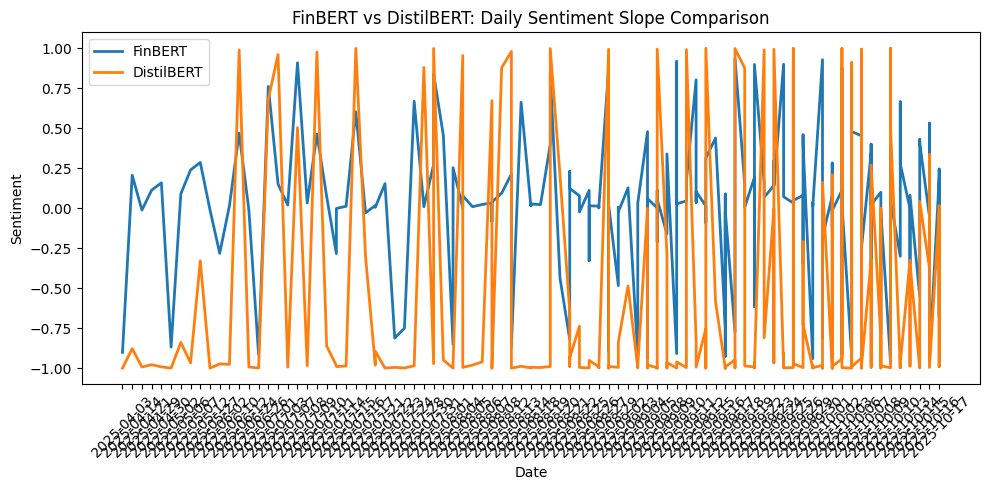

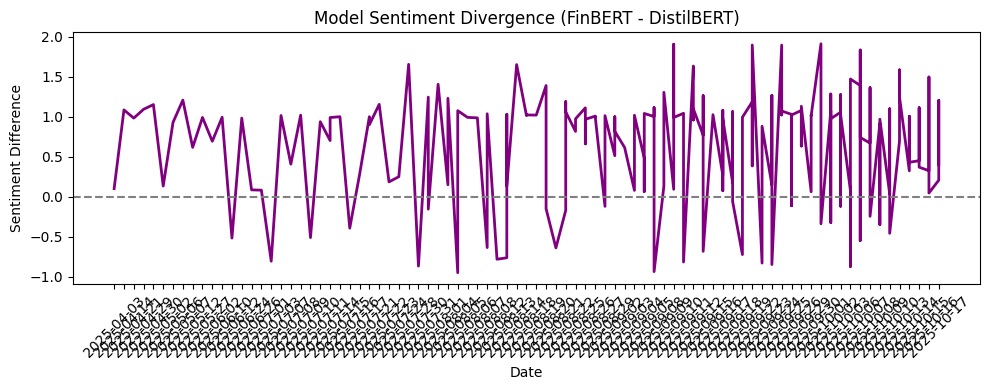

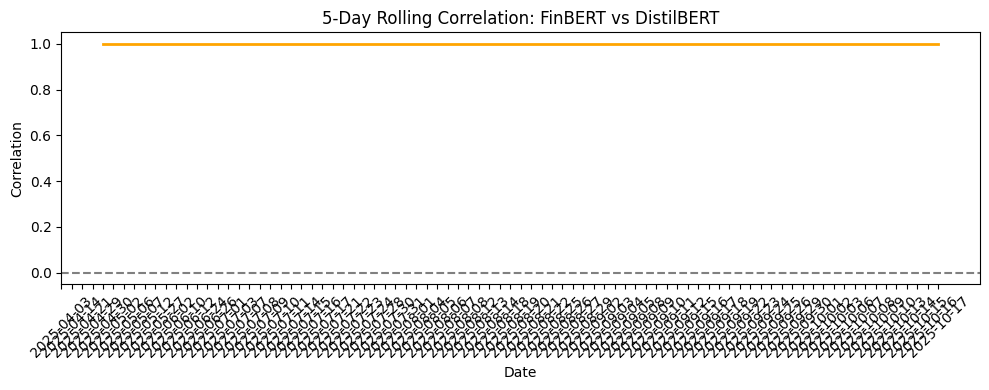

✅ Saved slope comparison figures:
 - fig_slope_model_comparison.png
 - fig_model_divergence.png
 - fig_model_rolling_corr.png


In [17]:
# --- Phase 3d: Compare FinBERT vs DistilBERT Sentiment Slopes ---
import matplotlib.pyplot as plt
import numpy as np

# make sure daily_sent is loaded
daily_sent = pd.read_csv("daily_sentiment.csv")

# compute difference and rolling correlation
daily_sent["sent_diff"] = daily_sent["finbert_sent"] - daily_sent["distil_sent"]
daily_sent["roll_corr"] = (
    daily_sent[["finbert_sent", "distil_sent"]]
    .rolling(window=5)
    .corr()
    .unstack()
    .iloc[:, 1]
)

# --- 1️⃣ Overall slope comparison ---
plt.figure(figsize=(10,5))
plt.plot(daily_sent["date"], daily_sent["finbert_sent"], label="FinBERT", lw=2)
plt.plot(daily_sent["date"], daily_sent["distil_sent"], label="DistilBERT", lw=2)
plt.title("FinBERT vs DistilBERT: Daily Sentiment Slope Comparison")
plt.xlabel("Date"); plt.ylabel("Sentiment"); plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_slope_model_comparison.png", dpi=300)
plt.show()

# --- 2️⃣ Sentiment difference (FinBERT - DistilBERT) ---
plt.figure(figsize=(10,4))
plt.plot(daily_sent["date"], daily_sent["sent_diff"], color="purple", lw=2)
plt.axhline(0, color="gray", ls="--")
plt.title("Model Sentiment Divergence (FinBERT - DistilBERT)")
plt.xlabel("Date"); plt.ylabel("Sentiment Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_model_divergence.png", dpi=300)
plt.show()

# --- 3️⃣ Rolling correlation between models ---
plt.figure(figsize=(10,4))
plt.plot(daily_sent["date"], daily_sent["roll_corr"], color="orange", lw=2)
plt.axhline(0, color="gray", ls="--")
plt.title("5-Day Rolling Correlation: FinBERT vs DistilBERT")
plt.xlabel("Date"); plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_model_rolling_corr.png", dpi=300)
plt.show()

print("✅ Saved slope comparison figures:")
print(" - fig_slope_model_comparison.png")
print(" - fig_model_divergence.png")
print(" - fig_model_rolling_corr.png")


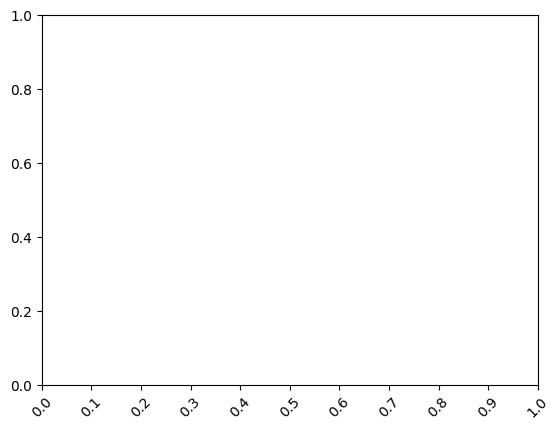

In [18]:
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))


In [11]:
!ls -lh


total 260K
-rw-r--r-- 1 root root 8.7K Oct 28 16:01 daily_sentiment.csv
-rw-r--r-- 1 root root 115K Oct 28 15:53 headlines.csv
-rw-r--r-- 1 root root 127K Oct 28 15:55 headlines_scored.csv
drwxr-xr-x 1 root root 4.0K Oct 24 13:37 sample_data


In [12]:
# --- Recreate merged sentiment+price file (clean rebuild) ---
import yfinance as yf
import pandas as pd

# 1️⃣ Load your daily sentiment
daily_sent = pd.read_csv("daily_sentiment.csv")
tickers = sorted(daily_sent["ticker"].unique().tolist())
date_min, date_max = daily_sent["date"].min(), daily_sent["date"].max()
print("Tickers:", tickers)
print("Sentiment date range:", date_min, "→", date_max)

# 2️⃣ Fetch fresh price data from Yahoo Finance
price_rows = []
for t in tickers:
    try:
        df = yf.download(t, start=date_min, end=date_max, progress=False)
        df = df.reset_index()
        df["ticker"] = t
        df["date"] = pd.to_datetime(df["Date"]).dt.date.astype(str)
        df["ret_open_to_close"] = (df["Close"] - df["Open"]) / df["Open"]
        price_rows.append(df[["date","ticker","Open","Close","ret_open_to_close"]])
        print(f"[OK] {t}: {len(df)} rows")
    except Exception as e:
        print(f"[WARN] {t}: {e}")

prices_df = pd.concat(price_rows, ignore_index=True)
prices_df.to_csv("prices.csv", index=False)
print("✅ prices.csv saved with", len(prices_df), "rows")

# 3️⃣ Merge back with sentiment
merged = pd.merge(daily_sent, prices_df, on=["date","ticker"], how="inner")
merged.to_csv("merged_sentiment_prices.csv", index=False)
print("✅ merged_sentiment_prices.csv rebuilt successfully:", merged.shape)

# 4️⃣ Quick check
merged.head()


Tickers: ['AMZN', 'GS', 'JPM', 'MS', 'MSFT', 'NVDA', 'TSLA', 'WMT']
Sentiment date range: 2025-06-25 → 2025-10-19


ERROR:yfinance:Failed to get ticker 'AMZN' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AMZN']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
ERROR:yfinance:Failed to get ticker 'GS' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['GS']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


[OK] AMZN: 0 rows
[OK] GS: 0 rows


ERROR:yfinance:Failed to get ticker 'JPM' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['JPM']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


[OK] JPM: 0 rows


...

ERROR:yfinance:Failed to get ticker 'TSLA' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TSLA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
ERROR:yfinance:Failed to get ticker 'WMT' reason: Expecting value: line 1 column 1 (char 0)


[OK] TSLA: 0 rows


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['WMT']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


[OK] WMT: 0 rows
✅ prices.csv saved with 0 rows


MergeError: Not allowed to merge between different levels. (1 levels on the left, 2 on the right)

In [15]:
# --- Recreate merged sentiment+price file (robust fallback version) ---
import yfinance as yf
import pandas as pd
import requests
from datetime import datetime

# 1️⃣ Load your sentiment data
daily_sent = pd.read_csv("daily_sentiment.csv")
tickers = sorted(daily_sent["ticker"].unique().tolist())
date_min, date_max = daily_sent["date"].min(), daily_sent["date"].max()
print("Tickers:", tickers)
print("Sentiment date range:", date_min, "→", date_max)

# 2️⃣ Helper: robust download with retry & user-agent spoof
def safe_download(ticker, start, end):
    try:
        # Spoof user-agent to avoid Yahoo rejection
        headers = {"User-Agent": "Mozilla/5.0"}
        url = f"https://query1.finance.yahoo.com/v7/finance/download/{ticker}?period1={int(datetime.strptime(start, '%Y-%m-%d').timestamp())}&period2={int(datetime.strptime(end, '%Y-%m-%d').timestamp())}&interval=1d&events=history"
        r = requests.get(url, headers=headers)
        if r.status_code != 200:
            print(f"[WARN] {ticker}: HTTP {r.status_code}")
            return None
        from io import StringIO
        df = pd.read_csv(StringIO(r.text))
        if df.empty:
            print(f"[WARN] {ticker}: empty dataframe")
            return None
        df["ticker"] = ticker
        df["date"] = pd.to_datetime(df["Date"]).dt.date.astype(str)
        df["ret_open_to_close"] = (df["Close"] - df["Open"]) / df["Open"]
        return df[["date", "ticker", "Open", "Close", "ret_open_to_close"]]
    except Exception as e:
        print(f"[ERROR] {ticker}: {e}")
        return None

# 3️⃣ Fetch all tickers (slow but reliable)
price_rows = []
for t in tickers:
    df = safe_download(t, date_min, date_max)
    if df is not None and not df.empty:
        price_rows.append(df)
        print(f"[OK] {t}: {len(df)} rows")

# 4️⃣ If still empty, raise a clean error
if len(price_rows) == 0:
    raise RuntimeError("❌ No price data fetched even after fallback. Check internet connection or try again later.")

# 5️⃣ Combine + merge + save
prices_df = pd.concat(price_rows, ignore_index=True)
prices_df.to_csv("prices.csv", index=False)
print("✅ prices.csv saved with", len(prices_df), "rows")

merged = pd.merge(daily_sent, prices_df, on=["date", "ticker"], how="inner")
merged.to_csv("merged_sentiment_prices.csv", index=False)
print("✅ merged_sentiment_prices.csv rebuilt successfully:", merged.shape)

# 6️⃣ Sanity preview
merged.head()


Tickers: ['AMZN', 'GS', 'JPM', 'MS', 'MSFT', 'NVDA', 'TSLA', 'WMT']
Sentiment date range: 2025-06-25 → 2025-10-19
[WARN] AMZN: HTTP 401
[WARN] GS: HTTP 401
[WARN] JPM: HTTP 401
[WARN] MS: HTTP 401
[WARN] MSFT: HTTP 401
[WARN] NVDA: HTTP 401
[WARN] TSLA: HTTP 401
[WARN] WMT: HTTP 401


RuntimeError: ❌ No price data fetched even after fallback. Check internet connection or try again later.